In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import Dataset
import evaluate
from transformers import (
    T5Tokenizer,
    T5ForConditionalGeneration,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
 )


C:\Users\Nisarg Patel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
train_data = pd.read_csv("samsum-train.csv")
val_data = pd.read_csv("samsum-validation.csv")


In [3]:
train_data.head()


,id,dialogue,summary
0,13818513,Amanda: I baked cookies. Do you want some?\r\...,Amanda baked cookies and will bring Jerry some...
1,13728867,Olivia: Who are you voting for in this electio...,Olivia and Olivier are voting for liberals in ...
2,13681000,"Tim: Hi, what's up?\r\nKim: Bad mood tbh, I wa...",Kim may try the pomodoro technique recommended...
3,13730747,"Edward: Rachel, I think I'm in ove with Bella....",Edward thinks he is in love with Bella. Rachel...
4,13728094,Sam: hey overheard rick say something\r\nSam:...,"Sam is confused, because he overheard Rick com..."


In [4]:
# Use the full dataset for training and validation
train_data = train_data.reset_index(drop=True)
val_data = val_data.reset_index(drop=True)


In [5]:
#data preprocessing
import re
def clean_data(text):
    # Handle possible NaN/float values
    text = str(text)
    # Remove special characters and extra spaces
    text = re.sub(r"\r\n", " ", text)
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"<.*?>", " ", text) # Fixed regex here from <,*?> to <.*?>
    text = text.strip()
    return text


In [6]:
train_data["dialogue"] = train_data["dialogue"].apply(clean_data)
train_data["summary"] = train_data["summary"].apply(clean_data)
val_data["dialogue"] = val_data["dialogue"].apply(clean_data)
val_data["summary"] = val_data["summary"].apply(clean_data)


In [7]:
#tokenization
tokenizer = T5Tokenizer.from_pretrained("t5-base")


In [8]:
# raw data => tokenized input for fine-tuning

def tokenize(data):
    # T5 models require a task prefix to identify summarization.
    text = "summarize: " + data["dialogue"]

    model_inputs = tokenizer(
        text,
        max_length=512,
        truncation=True,
    )
    labels = tokenizer(
        text_target=data["summary"],
        max_length=128,
        truncation=True,
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


In [9]:
train_dataset = Dataset.from_pandas(
    train_data[["dialogue", "summary"]],
    preserve_index=False,
 )
val_dataset = Dataset.from_pandas(
    val_data[["dialogue", "summary"]],
    preserve_index=False,
 )

train_dataset = train_dataset.map(
    tokenize,
    batched=False,
    remove_columns=["dialogue", "summary"],
 )
val_dataset = val_dataset.map(
    tokenize,
    batched=False,
    remove_columns=["dialogue", "summary"],
 )


Map:   0%|          | 0/14732 [00:00<?, ? examples/s]

Map:   0%|          | 0/818 [00:00<?, ? examples/s]

In [10]:
#working with our model
model = T5ForConditionalGeneration.from_pretrained("t5-base")


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

In [11]:
import torch

num_cuda_gpus = torch.cuda.device_count()
if num_cuda_gpus > 0:
    device = torch.device("cuda")
    for i in range(num_cuda_gpus):
        print(f"CUDA GPU {i}: {torch.cuda.get_device_name(i)}")
    # Enable TensorFloat32 on Ampere+ GPUs for faster matmul/convolution.
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
else:
    device = torch.device("cpu")

print(f"Using device: {device}")
print(f"CUDA-visible GPU count: {num_cuda_gpus}")
if num_cuda_gpus <= 1:
    print("Only one CUDA GPU is available; Intel UHD cannot be used by PyTorch CUDA training.")

model.to(device)

rouge = evaluate.load("rouge")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    if isinstance(predictions, tuple):
        predictions = predictions[0]

    predictions = np.array(predictions)
    labels = np.array(labels)

    # Some versions return logits during eval; convert logits -> token ids.
    if predictions.ndim == 3:
        predictions = np.argmax(predictions, axis=-1)

    # Guard against negative ids causing tokenizer decode overflow.
    predictions = np.where(predictions < 0, tokenizer.pad_token_id, predictions).astype(np.int64)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id).astype(np.int64)

    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds = [pred.strip() for pred in decoded_preds]
    decoded_labels = [label.strip() for label in decoded_labels]

    result = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True,
    )
    # Convert from [0,1] to percentage.
    result = {k: round(v * 100, 2) for k, v in result.items()}
    return result

data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)


CUDA GPU 0: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Using device: cuda
CUDA-visible GPU count: 1
Only one CUDA GPU is available; Intel UHD cannot be used by PyTorch CUDA training.


In [12]:
# training arguments
import inspect
import platform

seq2seq_params = inspect.signature(Seq2SeqTrainingArguments.__init__).parameters

def set_strategy_arg(args_dict, preferred_key, fallback_key, value):
    if preferred_key in seq2seq_params:
        args_dict[preferred_key] = value
    elif fallback_key in seq2seq_params:
        args_dict[fallback_key] = value

def set_optional_arg(args_dict, key, value):
    if key in seq2seq_params:
        args_dict[key] = value

is_bf16 = bool(
    torch.cuda.is_available()
    and hasattr(torch.cuda, "is_bf16_supported")
    and torch.cuda.is_bf16_supported()
 )
is_windows = platform.system().lower().startswith("win")

base_args = dict(
    output_dir="./results",
    num_train_epochs=10,
    learning_rate=1e-4,
    weight_decay=0.01,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=16,

    eval_steps=500,
    save_steps=500,
    logging_steps=100,
    warmup_steps=500,

    predict_with_generate=True,
    generation_max_length=64,
    generation_num_beams=2,

    load_best_model_at_end=True,
    metric_for_best_model="rougeL",
    greater_is_better=True,
    save_total_limit=2,

    dataloader_num_workers=0 if is_windows else 2,
    dataloader_pin_memory=torch.cuda.is_available(),
    report_to="none",
)

set_strategy_arg(base_args, "evaluation_strategy", "eval_strategy", "steps")
set_strategy_arg(base_args, "save_strategy", "save_strategy", "steps")
set_strategy_arg(base_args, "logging_strategy", "logging_strategy", "steps")

# Optional speed/throughput settings applied only when supported by the installed version.
set_optional_arg(base_args, "bf16", is_bf16)
set_optional_arg(base_args, "fp16", torch.cuda.is_available() and not is_bf16)
set_optional_arg(base_args, "group_by_length", True)
set_optional_arg(base_args, "gradient_checkpointing", not is_windows)
set_optional_arg(base_args, "ddp_find_unused_parameters", False)
set_optional_arg(base_args, "eval_accumulation_steps", 8)
set_optional_arg(base_args, "optim", "adamw_torch_fused")

training_args = Seq2SeqTrainingArguments(**base_args)

print(f"Windows mode: {is_windows}; dataloader_num_workers={base_args['dataloader_num_workers']}")

Windows mode: True; dataloader_num_workers=0


In [13]:
trainer_kwargs = dict(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
)

trainer_params = inspect.signature(Seq2SeqTrainer.__init__).parameters
if "processing_class" in trainer_params:
    trainer_kwargs["processing_class"] = tokenizer
elif "tokenizer" in trainer_params:
    trainer_kwargs["tokenizer"] = tokenizer

trainer = Seq2SeqTrainer(**trainer_kwargs)


In [14]:
from transformers.trainer_utils import get_last_checkpoint

last_checkpoint = get_last_checkpoint("./results")

if last_checkpoint is not None:
    print(f"Resuming training from {last_checkpoint}...")
    try:
        trainer.train(resume_from_checkpoint=last_checkpoint)
    except Exception as exc:
        print(f"Checkpoint resume failed ({exc}). Starting training from scratch...")
        trainer.train()
else:
    print("No checkpoint found. Starting training from scratch...")
    trainer.train()


Resuming training from ./results\checkpoint-4000...


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


KeyboardInterrupt: 

In [15]:
model.save_pretrained("./saved_summarizer_model")
tokenizer.save_pretrained("./saved_summarizer_model")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./saved_summarizer_model\\tokenizer_config.json',
 './saved_summarizer_model\\tokenizer.json')

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Evaluating with num_beams=4, max_length=128 (was 2, 64)


Validation scores (sample):
ROUGE-1: 52.27
ROUGE-2: 27.99
ROUGE-L: 43.43
ROUGE-Lsum: 43.44
Overlap Accuracy: 45.14


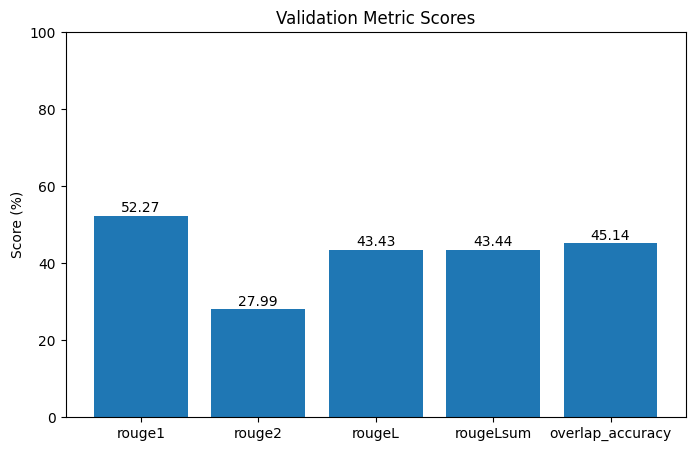

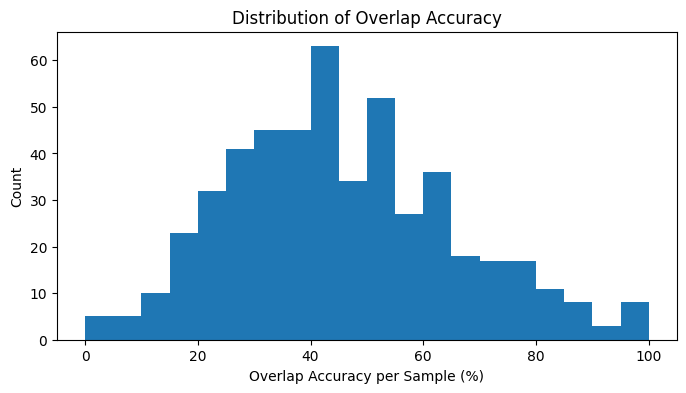

In [16]:
# post-training evaluation on a validation sample + score graphs
sample_size = min(500, len(val_data))
val_sample = val_data.iloc[:sample_size].copy()

val_sample_ds = Dataset.from_pandas(
    val_sample[["dialogue", "summary"]],
    preserve_index=False,
 )
val_sample_ds = val_sample_ds.map(
    tokenize,
    batched=False,
    remove_columns=["dialogue", "summary"],
 )

# --- Quick Fix: boost beam width + max length for better ROUGE-2 (no retraining needed) ---
_orig_beams = trainer.args.generation_num_beams
_orig_max_len = trainer.args.generation_max_length
trainer.args.generation_num_beams = 4
trainer.args.generation_max_length = 128
print(f"Evaluating with num_beams=4, max_length=128 (was {_orig_beams}, {_orig_max_len})")

pred_output = trainer.predict(val_sample_ds, metric_key_prefix="val")

# Restore original generation settings
trainer.args.generation_num_beams = _orig_beams
trainer.args.generation_max_length = _orig_max_len
pred_ids = pred_output.predictions
if isinstance(pred_ids, tuple):
    pred_ids = pred_ids[0]

pred_ids = np.array(pred_ids)
if pred_ids.ndim == 3:
    pred_ids = np.argmax(pred_ids, axis=-1)
pred_ids = np.where(pred_ids < 0, tokenizer.pad_token_id, pred_ids).astype(np.int64)

pred_texts = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
ref_texts = val_sample["summary"].tolist()

pred_texts = [p.strip() for p in pred_texts]
ref_texts = [r.strip() for r in ref_texts]

rouge_scores = rouge.compute(
    predictions=pred_texts,
    references=ref_texts,
    use_stemmer=True,
 )
rouge_scores_pct = {k: round(v * 100, 2) for k, v in rouge_scores.items()}

def token_overlap_accuracy(pred, ref):
    pred_tokens = set(pred.lower().split())
    ref_tokens = set(ref.lower().split())
    if not ref_tokens:
        return 0.0
    return len(pred_tokens & ref_tokens) / len(ref_tokens)

overlap_scores = [
    token_overlap_accuracy(pred, ref)
    for pred, ref in zip(pred_texts, ref_texts)
 ]
overlap_accuracy = round(float(np.mean(overlap_scores)) * 100, 2)

print("Validation scores (sample):")
print(f"ROUGE-1: {rouge_scores_pct['rouge1']}")
print(f"ROUGE-2: {rouge_scores_pct['rouge2']}")
print(f"ROUGE-L: {rouge_scores_pct['rougeL']}")
print(f"ROUGE-Lsum: {rouge_scores_pct['rougeLsum']}")
print(f"Overlap Accuracy: {overlap_accuracy}")

metric_names = ["rouge1", "rouge2", "rougeL", "rougeLsum", "overlap_accuracy"]
metric_values = [
    rouge_scores_pct["rouge1"],
    rouge_scores_pct["rouge2"],
    rouge_scores_pct["rougeL"],
    rouge_scores_pct["rougeLsum"],
    overlap_accuracy,
 ]

plt.figure(figsize=(8, 5))
plt.bar(metric_names, metric_values)
plt.ylim(0, 100)
plt.ylabel("Score (%)")
plt.title("Validation Metric Scores")
for i, v in enumerate(metric_values):
    plt.text(i, min(v + 1, 99), f"{v:.2f}", ha="center")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist([score * 100 for score in overlap_scores], bins=20)
plt.xlabel("Overlap Accuracy per Sample (%)")
plt.ylabel("Count")
plt.title("Distribution of Overlap Accuracy")
plt.show()


In [17]:
model= T5ForConditionalGeneration.from_pretrained("./saved_summarizer_model")
tokenizer= T5Tokenizer.from_pretrained("./saved_summarizer_model")


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

In [18]:
# testing core logic of text summarization
def summarize_dialogue(text):
    # Add the T5 task prefix.
    text = "summarize: " + text

    inputs = tokenizer(
        text,
        return_tensors="pt",
        padding="max_length",
        max_length=512,
        truncation=True,
    ).to(device)
    model.to(device)
    model.eval()

    with torch.no_grad():
        target = model.generate(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_length=64,
            min_length=10,
            num_beams=4,
            no_repeat_ngram_size=2,
            early_stopping=True,
        )

    summary = tokenizer.decode(target[0], skip_special_tokens=True)
    return summary


In [19]:
test_dialogue = '''
Benjamin: Hey guys, what are we doing with the keys today?
Hilary: I've got them. Whoever wants them can meet me at lunchtime or after
Elliot: I'm ok. We're meeting for the drinks in the evening anyway and I guess we'll be going back to the apartment together?
Hilary: Yeah, I guess so
Daniel: I'm with Hilary atm and won't let go of her for the rest of the day, so any option you guys choose is good for me
Benjamin: Hmm I might actually pass by at lunchtime, take the keys and go take a nap. I'm sooo tired after yesterday
Hilary: Sounds good. We'll be having lunch with some French people (the ones who work on the history of food in colonial Mexico - I already see you yawning your head off)
Benjamin: YAAAAWN 🙊 Where and where are you meeting?
Hilary: So I'm meeting them at the entrance to the conference hall at 2 pm and then we'll head to this place called La Cantina. Italian cuisine, which is quite funny, but that's what they've chosen
Benjamin: Interesting 😱 To be honest, Hilary, I almost feel like changing my mind. Wanting to take this nap might end up costing me to dear
Hilary: Oh come on 😂
Benjamin: All these terrible obstacles on mu way to bed might just prove to much to take
Hilary: We'll try to avoid talking about their subject of research. Oh wait, no, I'm actually meeting them because I wanted to chat about their research lol
Elliot: 🙉
Hilary: Do join us, we're going to have fun. And then you'll take the keys and take this most deserved of naps
Elliot: Sounds like a plan 😂
Hilary: 😎
Elliot: See you at 2 then xx
'''
summary = summarize_dialogue(test_dialogue)
print("Summary:", summary)


Summary: Benjamin, Hilary and Elliot are going to meet for drinks in the evening and go back to the apartment together. Benjamin will take the keys and take a nap. They will have lunch with French people who work on the history of food in colonial Mexico.
